Level 2 now works directly in logit space using the official get_component_cos_xpy / get_component_sin_xpy functions. Components are the cos(k(a+b)) and sin(k(a+b)) Fourier directions in the final logits: exactly what Section 4.4 and Figure 6 of the paper test.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import einops
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level2")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
L1_RESULTS = Path("../results/level1/level1_results.json")
MODEL_PATH  = Path("../data/grokking_model.pt")

Using device: cpu


Dataset and Model

In [ ]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels_all = (aa + bb) % P
inputs_all  = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs_all)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs_all[idx[n_test:]]
test_inputs  = inputs_all[idx[:n_test]]
test_labels  = labels_all[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:, -1, :].argmax(-1) == test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}  ✓")

Moving model to device:  cpu
Test accuracy: 1.0000  ✓


Build Fourier basis and key frequency helpers (official code)

In [ ]:
# Orthonormal Fourier basis — identical to official notebook
fourier_basis= [torch.ones(P) / np.sqrt(P)]
fourier_basis_names = ['Const']

for i in range(1, P // 2 + 1):
    cos_v = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_v = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    fourier_basis.append(cos_v / cos_v.norm())
    fourier_basis.append(sin_v / sin_v.norm())
    fourier_basis_names.append(f'cos {i}')
    fourier_basis_names.append(f'sin {i}')

fourier_basis = torch.stack(fourier_basis, dim=0).to(device)   # [113, 113]

def fourier_2d_basis_term(x_index, y_index):
    """Outer product of two 1D Fourier basis vectors, flattened to [p^2]."""
    return (fourier_basis[x_index][:, None] * fourier_basis[y_index][None, :]).flatten()

def get_component_cos_xpy(logits, freq):
    """
    Projects logits onto the cos(freq*(a+b)) direction in 2D Fourier space.
    logits shape: [p*p, p]
    Returns same shape: the projection component only.
    (Direct translation from official notebook)
    """
    cosx_cosy = fourier_2d_basis_term(2 * freq - 1, 2 * freq - 1)
    sinx_siny = fourier_2d_basis_term(2 * freq, 2 * freq)
    cos_xpy = (cosx_cosy - sinx_siny) / np.sqrt(2)   # [p^2]
    return cos_xpy[:, None] * (cos_xpy[None, :] @ logits)   # [p^2, p]

def get_component_sin_xpy(logits, freq):
    """Projects logits onto the sin(freq*(a+b)) direction."""
    sinx_cosy = fourier_2d_basis_term(2 * freq,     2 * freq - 1)
    cosx_siny = fourier_2d_basis_term(2 * freq - 1, 2 * freq)
    sin_xpy = (sinx_cosy + cosx_siny) / np.sqrt(2)   # [p^2]
    return sin_xpy[:, None] * (sin_xpy[None, :] @ logits)   # [p^2, p]

print("Fourier basis and helper functions ready.")

Fourier basis and helper functions ready.


Load key frequencies from Level 1 results

In [4]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
KEY_FREQS = l1["key_freqs"]
print(f"Key frequencies (from Level 1): {KEY_FREQS}")

Key frequencies (from Level 1): [3, 14, 1]


Define components: one cos + one sin per key frequency

In [ ]:
# Each component is a (frequency, cos/sin) Fourier direction in logit space
# This directly matches the official paper's ablation 
COMPONENTS = []
for k in KEY_FREQS:
    COMPONENTS.append({"name": f"cos_{k}", "k": k, "part": "cos"})
    COMPONENTS.append({"name": f"sin_{k}", "k": k, "part": "sin"})

print(f"Level 2 components: {len(COMPONENTS)}")
for c in COMPONENTS:
    print(f"  {c['name']}")
print(f"\nTotal component space: {len(COMPONENTS)}  "
      f"(2 directions per key frequency)")

Level 2 components: 6
  cos_3
  sin_3
  cos_14
  sin_14
  cos_1
  sin_1

Total component space: 6  (2 directions per key frequency)


Run model on ALL inputs (p*p) to get full logit tensor

In [ ]:
# We need all p*p logits to work in the 2D Fourier basis
# (following official notebook)
all_inputs_dev = inputs_all.to(device)    # [p*p, 3]
all_labels_dev = labels_all.to(device)    # [p*p]

with torch.no_grad():
    all_logits = model(all_inputs_dev)[:, -1, :]   # [p*p, p]

print(f"Full logit tensor shape: {all_logits.shape}")
print(f"Original loss (all data): " f"{torch.nn.CrossEntropyLoss()(all_logits, all_labels_dev):.6f}")

Full logit tensor shape: torch.Size([12769, 113])
Original loss (all data): 0.005559


Faithfulness metric — logit of correct token (consistent with Level 1 and Level 3)

In [ ]:
def logit_of_correct_all(logits, labels):
    """Logit assigned to the correct answer for each input; shape [p*p]."""
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    """RS = (patched - corrupted).mean / (clean - corrupted).mean
    Consistent with Level 1 and Level 3 grokking notebooks."""
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

# Clean baseline
clean_metric = logit_of_correct_all(all_logits, all_labels_dev)
clean_acc    = (all_logits.argmax(-1) == all_labels_dev).float().mean().item()

# Corrupted baseline: zero out ALL key-frequency components from the logits
corrupted_logits = all_logits.clone()
for k in KEY_FREQS:
    corrupted_logits = corrupted_logits \
        - get_component_cos_xpy(corrupted_logits, k) \
        - get_component_sin_xpy(corrupted_logits, k)

corrupted_metric = logit_of_correct_all(corrupted_logits, all_labels_dev)
corrupted_acc    = (corrupted_logits.argmax(-1) == all_labels_dev).float().mean().item()

print(f"Clean     logit(correct): {clean_metric.mean():.4f}  acc={clean_acc:.4f}")
print(f"Corrupted logit(correct): {corrupted_metric.mean():.4f}  acc={corrupted_acc:.4f}")
print(f"Gap to recover: {(clean_metric - corrupted_metric).mean():.4f}")

Per-component patching loop

For each component, remove all key frequency components from the logits, then restore just this one. This is the direct logit-space analogue of activation patching.

In [ ]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching frequency components"):
    cname = comp["name"]
    k     = comp["k"]
    part  = comp["part"]

    # Start from fully corrupted logits (all key freqs removed)
    patched = all_logits.clone()
    for kk in KEY_FREQS:
        patched = patched \
            - get_component_cos_xpy(patched, kk) \
            - get_component_sin_xpy(patched, kk)

    # Restore just this one component from the clean logits
    if part == "cos":
        patched = patched + get_component_cos_xpy(all_logits, k)
    else:
        patched = patched + get_component_sin_xpy(all_logits, k)

    patched_metric = logit_of_correct_all(patched, all_labels_dev)
    scores[cname]  = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  {cname:10s}  logit(correct)={patched_metric.mean():.4f}  RS={scores[cname]:.4f}")

Criterion 1 and Criterion2

In [ ]:
sorted_comps  = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_comps]
scores_sorted = torch.tensor([x[1] for x in sorted_comps])

pos_scores = scores_sorted.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_components = names_sorted[:k_95]

# Criterion 1: restore all circuit components together, measure logit(correct)
circuit_logits = all_logits.clone()
for kk in KEY_FREQS:
    circuit_logits = circuit_logits \
        - get_component_cos_xpy(circuit_logits, kk) \
        - get_component_sin_xpy(circuit_logits, kk)

for cname in circuit_components:
    comp = next(c for c in COMPONENTS if c["name"] == cname)
    if comp["part"] == "cos":
        circuit_logits = circuit_logits + get_component_cos_xpy(all_logits, comp["k"])
    else:
        circuit_logits = circuit_logits + get_component_sin_xpy(all_logits, comp["k"])

circuit_metric = logit_of_correct_all(circuit_logits, all_labels_dev)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

print("=" * 55)
print("  Level 2 — Logit-space Fourier components")
print("=" * 55)
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {len(COMPONENTS)}")
print(f"               Compression ratio: {k_95/len(COMPONENTS):.3f}")
print(f"  Circuit components: {circuit_components}")
print("=" * 55)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if n in circuit_components else "lightgray" for n in names_sorted]
ax1.bar(names_sorted, scores_sorted.numpy(), color=colors)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-component RS — Level 2 (Fourier logit directions)")
ax1.tick_params(axis="x", rotation=30)

ax2.plot(range(1, len(COMPONENTS) + 1), cumulative.numpy() / total_pos, "o-", color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--", label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Components included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 2")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level2_recovery_scores.png", dpi=150)
plt.show()

Save Results

In [ ]:
results = {
    "level": 2,
    "task": "modular_arithmetic_mod113",
    "method": "logit_fourier_components",
    "metric": "logit_of_correct_token",
    "key_freqs": KEY_FREQS,
    "n_components": len(COMPONENTS),
    "components": [c["name"] for c in COMPONENTS],
    "clean_metric_mean":      clean_metric.mean().item(),
    "corrupted_metric_mean":  corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / len(COMPONENTS),
    "circuit_components": circuit_components,
    "all_recovery_scores": scores,
}

with open(RESULTS_DIR / "level2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level2_results.json")

## OLD VERSION 2

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level2")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

L1_RESULTS = Path("../results/level1/level1_results.json")
MODEL_PATH  = Path("../data/grokking_model.pt")

Using device: cpu


Rebuild the dataset and model

Identical to the Level 1 notebook — we need both to evaluate the circuit. Because the model was saved to disk in the previous notebook, this cell should load instantly.

In [49]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs  = inputs[idx[:n_test]]
test_labels  = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,   #enables blocks.0.attn.hook_result
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1)== test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}")

Moving model to device:  cpu
Test accuracy: 1.0000


In [50]:
# Key frequencies identified by Nanda et al. for mod-113 grokking
# We'll discover ours empirically from WL, then patch by frequency

# Step 1: identify key frequencies from the neuron-logit map
WU = model.W_U                          # [d_model, d_vocab] = [128, 113]
W_out = model.blocks[0].mlp.W_out       # [d_mlp, d_model] = [512, 128]
WL = W_out @ WU                      # [512, 113] — neuron-logit map

# Take DFT along the logit (output) axis
WL_fft = torch.fft.rfft(WL, dim=0)      # [57, 512]
WL_norms = WL_fft.abs().norm(dim=1)     # [57] — norm over neuron axis

# Find top frequencies (excluding DC component k=0)
WL_norms[0] = 0
top_k_idx = WL_norms.topk(20).indices.sort().values
KEY_FREQS = top_k_idx.tolist()

print(f"Key frequencies identified from WL: {KEY_FREQS}")
print("(Compare with Nanda et al. mainline: [14, 35, 41, 42, 52])")

Key frequencies identified from WL: [24, 29, 42, 57, 71, 91, 93, 103, 104, 121, 147, 160, 178, 179, 182, 187, 193, 201, 204, 253]
(Compare with Nanda et al. mainline: [14, 35, 41, 42, 52])


In [51]:
P = 113

# For each key frequency k, build the sine and cosine basis vectors over outputs
# These are the directions in logit space that the model uses
freq_components = []
for k in KEY_FREQS:
    c_vals = torch.arange(P).float()
    cos_vec = torch.cos(2 * torch.pi * k * c_vals / P)  # [113]
    sin_vec = torch.sin(2 * torch.pi * k * c_vals / P)  # [113]
    freq_components.append({"k": k, "cos": cos_vec, "sin": sin_vec})

# The corresponding directions in the residual stream (via WL)
# uk = direction in MLP activation space for cos(wk*c)
# These are what the MLP writes along to produce the Fourier outputs
WL_np = WL.detach().numpy()
freq_directions = {}
for fc in freq_components:
    k = fc["k"]
    cos_dir = torch.tensor(WL_np @ fc["cos"].numpy())  # [512]
    sin_dir = torch.tensor(WL_np @ fc["sin"].numpy())  # [512]
    cos_dir = cos_dir / (cos_dir.norm() + 1e-8)
    sin_dir = sin_dir / (sin_dir.norm() + 1e-8)
    freq_directions[k] = {"cos_dir": cos_dir, "sin_dir": sin_dir}

print(f"Built frequency directions for k = {KEY_FREQS}")
print(f"Each direction shape: {cos_dir.shape}")

Built frequency directions for k = [24, 29, 42, 57, 71, 91, 93, 103, 104, 121, 147, 160, 178, 179, 182, 187, 193, 201, 204, 253]
Each direction shape: torch.Size([512])


In [52]:
# The correct hook for Level 2: the full residual stream AFTER attention, BEFORE MLP
# This captures everything the attention mechanism contributes to the MLP's input
RESID_MID_HOOK = "blocks.0.hook_resid_mid"

# Components: one per (frequency, sin/cos) pair + the full attention block as a unit
# Total: 2 * len(KEY_FREQS) frequency components + 1 full attention component
COMPONENTS = []
for k in KEY_FREQS:
    COMPONENTS.append({"name": f"freq_{k}_cos", "k": k, "part": "cos"})
    COMPONENTS.append({"name": f"freq_{k}_sin", "k": k, "part": "sin"})
COMPONENTS.append({"name": "attn_full", "k": None, "part": "full"})

print(f"Level 2 components: {len(COMPONENTS)}")
for c in COMPONENTS:
    print(f"  {c['name']}")

Level 2 components: 41
  freq_24_cos
  freq_24_sin
  freq_29_cos
  freq_29_sin
  freq_42_cos
  freq_42_sin
  freq_57_cos
  freq_57_sin
  freq_71_cos
  freq_71_sin
  freq_91_cos
  freq_91_sin
  freq_93_cos
  freq_93_sin
  freq_103_cos
  freq_103_sin
  freq_104_cos
  freq_104_sin
  freq_121_cos
  freq_121_sin
  freq_147_cos
  freq_147_sin
  freq_160_cos
  freq_160_sin
  freq_178_cos
  freq_178_sin
  freq_179_cos
  freq_179_sin
  freq_182_cos
  freq_182_sin
  freq_187_cos
  freq_187_sin
  freq_193_cos
  freq_193_sin
  freq_201_cos
  freq_201_sin
  freq_204_cos
  freq_204_sin
  freq_253_cos
  freq_253_sin
  attn_full


In [53]:
all_resid = []
with torch.no_grad():
    for i in range(0, len(train_inputs), 256):
        batch = train_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=RESID_MID_HOOK)
        all_resid.append(cache[RESID_MID_HOOK][:, -1, :].cpu())

mean_resid = torch.cat(all_resid, dim=0).mean(dim=0)   # [d_model]
print(f"Mean residual stream shape: {mean_resid.shape}")

Mean residual stream shape: torch.Size([128])


In [54]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched, corrupted, clean):
    gap = (clean - corrupted).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched.mean().item() - corrupted.mean().item()) / gap

N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=RESID_MID_HOOK)
clean_resid = cache[RESID_MID_HOOK][:, -1, :]   # [N_EVAL, d_model]

# Corrupted: replace entire resid_mid at "=" position with its mean
mean_r = mean_resid.to(device)
def full_ablation_hook(value, hook):
    value[:, -1, :] = mean_r
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(RESID_MID_HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:     {clean_metric.mean():.4f}")
print(f"Corrupted metric: {corrupted_metric.mean():.4f}")
print(f"Gap to recover:   {(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:     42.8277
Corrupted metric: -2.1187
Gap to recover:   44.9464


In [55]:
freq_directions = {}

for fc in freq_components:
    k = fc["k"]

    # neuron-space coefficients
    cos_neuron = WL @ fc["cos"]   # [512]
    sin_neuron = WL @ fc["sin"]   # [512]

    # map to residual stream
    cos_resid = cos_neuron @ W_out   # [128]
    sin_resid = sin_neuron @ W_out   # [128]

    # normalize
    cos_resid = cos_resid / (cos_resid.norm() + 1e-8)
    sin_resid = sin_resid / (sin_resid.norm() + 1e-8)

    freq_directions[k] = {
        "cos_dir": cos_resid,
        "sin_dir": sin_resid,
    }

In [56]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching frequency components"):
    name = comp["name"]

    if comp["part"] == "full":
        # Restore the entire residual stream at "=" position
        def hook_fn(value, hook, cr=clean_resid):
            value[:, -1, :] = cr.to(value.device)
            return value
    else:
        k    = comp["k"]
        part = comp["part"]
        direction = freq_directions[k][f"{part}_dir"].to(device)  # [d_model]

        def hook_fn(value, hook,
                    cr=clean_resid, m=mean_r, d=direction):
            # Start from mean-ablated residual
            patched = m.unsqueeze(0).expand(N_EVAL, -1).clone()
            # Restore only the component of clean resid along this direction
            projection = (cr.to(value.device) * d).sum(dim=-1, keepdim=True) * d
            patched = patched + projection
            value[:, -1, :] = patched
            return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(RESID_MID_HOOK, hook_fn)])[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[name] = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  {name:20s}  RS = {scores[name]:.4f}")

Patching frequency components:   0%|          | 0/41 [00:00<?, ?it/s]

  freq_24_cos           RS = 0.0049
  freq_24_sin           RS = 0.0041
  freq_29_cos           RS = 0.0013
  freq_29_sin           RS = 0.0009
  freq_42_cos           RS = 0.0004
  freq_42_sin           RS = 0.0003
  freq_57_cos           RS = 0.0053
  freq_57_sin           RS = 0.0060
  freq_71_cos           RS = 0.0004
  freq_71_sin           RS = 0.0003
  freq_91_cos           RS = 0.0146
  freq_91_sin           RS = 0.0050
  freq_93_cos           RS = 0.0002
  freq_93_sin           RS = 0.0003
  freq_103_cos          RS = 0.0028
  freq_103_sin          RS = -0.0008
  freq_104_cos          RS = 0.0009
  freq_104_sin          RS = 0.0127
  freq_121_cos          RS = 0.0025
  freq_121_sin          RS = 0.0046
  freq_147_cos          RS = 0.0089
  freq_147_sin          RS = 0.0019
  freq_160_cos          RS = 0.0060
  freq_160_sin          RS = 0.0020
  freq_178_cos          RS = 0.0019
  freq_178_sin          RS = 0.0024
  freq_179_cos          RS = 0.0060
  freq_179_sin          RS 

In [57]:
sorted_components = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_components]
scores_sorted = torch.tensor([x[1] for x in sorted_components])

pos_scores = scores_sorted.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_components = names_sorted[:k_95]

# Criterion 1: run circuit together
def circuit_hook(value, hook):
    patched = mean_r.unsqueeze(0).expand(N_EVAL, -1).clone().to(value.device)
    for cname in circuit_components:
        comp = next(c for c in COMPONENTS if c["name"] == cname)
        if comp["part"] == "full":
            patched = clean_resid.clone().to(value.device)
            break
        k    = comp["k"]
        part = comp["part"]
        d    = freq_directions[k][f"{part}_dir"].to(value.device)
        proj = (clean_resid.to(value.device) * d).sum(dim=-1, keepdim=True) * d
        patched = patched + proj
    value[:, -1, :] = patched
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(RESID_MID_HOOK, circuit_hook)])[:, -1, :]
circuit_metric = logit_of_correct(circuit_logits, eval_y)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

print("=" * 55)
print("  Level 2 — Fourier frequency components (resid_mid)")
print("=" * 55)
print(f"  Key frequencies found: {KEY_FREQS}")
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {len(COMPONENTS)}")
print(f"               Compression ratio: {k_95/len(COMPONENTS):.3f}")
print(f"\n  Circuit components: {circuit_components}")
print("=" * 55)

  Level 2 — Fourier frequency components (resid_mid)
  Key frequencies found: [24, 29, 42, 57, 71, 91, 93, 103, 104, 121, 147, 160, 178, 179, 182, 187, 193, 201, 204, 253]
  Criterion 1  Faithfulness RS : 1.0000
  Criterion 2  Component count : 12 / 41
               Compression ratio: 0.293

  Circuit components: ['attn_full', 'freq_204_cos', 'freq_91_cos', 'freq_104_sin', 'freq_187_sin', 'freq_147_cos', 'freq_201_sin', 'freq_57_sin', 'freq_179_cos', 'freq_160_cos', 'freq_193_sin', 'freq_57_cos']


OLD APPROACH


Define position-aware components

In [23]:
# Positions in the input sequence: [a, b, =]
# The model predicts at position 2 (the "=" token)
POS_NAMES = {0: "pos_a", 1: "pos_b", 2: "pos_eq"}

# Build all (name, hook_point, head_idx, position) combinations
# 4 heads x 3 positions = 12 attention components
# 1 MLP x 3 positions = 3 MLP components
# Total: 15 components

COMPONENTS = []
for pos in range(3):
    for h in range(4):
        COMPONENTS.append({
            "name":       f"head_{h}_{POS_NAMES[pos]}",
            "hook":       "blocks.0.attn.hook_result",
            "head_idx":   h,
            "pos":        pos,
        })
    COMPONENTS.append({
        "name":     f"mlp_{POS_NAMES[pos]}",
        "hook":     "blocks.0.hook_mlp_out",
        "head_idx": None,
        "pos":      pos,
    })

HOOKS = list({c["hook"] for c in COMPONENTS})

print("Level 2 components:")
for c in COMPONENTS:
    print(f"{c['name']:25s}  hook={c['hook']}")
print(f"\nTotal component space: {len(COMPONENTS)}")

Level 2 components:
head_0_pos_a               hook=blocks.0.attn.hook_result
head_1_pos_a               hook=blocks.0.attn.hook_result
head_2_pos_a               hook=blocks.0.attn.hook_result
head_3_pos_a               hook=blocks.0.attn.hook_result
mlp_pos_a                  hook=blocks.0.hook_mlp_out
head_0_pos_b               hook=blocks.0.attn.hook_result
head_1_pos_b               hook=blocks.0.attn.hook_result
head_2_pos_b               hook=blocks.0.attn.hook_result
head_3_pos_b               hook=blocks.0.attn.hook_result
mlp_pos_b                  hook=blocks.0.hook_mlp_out
head_0_pos_eq              hook=blocks.0.attn.hook_result
head_1_pos_eq              hook=blocks.0.attn.hook_result
head_2_pos_eq              hook=blocks.0.attn.hook_result
head_3_pos_eq              hook=blocks.0.attn.hook_result
mlp_pos_eq                 hook=blocks.0.hook_mlp_out

Total component space: 15


Compute mean activations per hook point

Unchanged from before — we still just need the mean tensor at every position (shape [seq, n_heads, d_model] for attention, [seq, d_model] for MLP). The position dimension is preserved here so we can index into it during patching.

In [24]:
mean_acts = {}

for hook_point in HOOKS:
    all_acts = []
    with torch.no_grad():
        for i in range(0, len(train_inputs), 256):
            batch = train_inputs[i:i+256].to(device)
            _, cache = model.run_with_cache(batch, names_filter=hook_point)
            all_acts.append(cache[hook_point].cpu())   # full [batch, seq, ...]
    mean_acts[hook_point] = torch.cat(all_acts, dim=0).mean(dim=0)  # [seq, ...]

for k, v in mean_acts.items():
    print(f"{k}: mean shape = {v.shape}")
# attn: [3, n_heads, d_model]
# mlp:  [3, d_model]

blocks.0.attn.hook_result: mean shape = torch.Size([3, 4, 128])
blocks.0.hook_mlp_out: mean shape = torch.Size([3, 128])


Faithfulness metric (same as Level 1)

In [25]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

Clean and fully corrupted baselines

The fully corrupted run mean-ablates every component at every position simultaneously 

In [26]:
N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean run
with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

# Cache clean activations for all hook points
with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=HOOKS)
clean_acts = {h: cache[h] for h in HOOKS}
# attn: [N_EVAL, seq, n_heads, d_model]
# mlp:  [N_EVAL, seq, d_model]

# Full ablation: replace every component at every position with its mean
def make_full_ablation_hooks():
    hooks = []
    for hook_point in HOOKS:
        mean = mean_acts[hook_point].to(device)  # [seq, ...]
        def h(value, hook, m=mean):
            # value shape: [batch, seq, n_heads, d_model] or [batch, seq, d_model]
            value[:] = m.unsqueeze(0).expand_as(value)
            return value
        hooks.append((hook_point, h))
    return hooks

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=make_full_ablation_hooks())[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:{clean_metric.mean():.4f}")
print(f"Corrupted metric:{corrupted_metric.mean():.4f}")
print(f"Gap to recover:{(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:42.8277
Corrupted metric:-11.2612
Gap to recover:54.0890


Component-level patching loop

For each of the 15 components: ablate everything at every position, then restore just this one (head h, position p) to its clean value.

In [27]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching components"):
    cname = comp["name"]
    c_hook = comp["hook"]
    c_head = comp["head_idx"]
    c_pos = comp["pos"]

    def make_hooks(target_hook, target_head, target_pos):
        hooks = []
        for hook_point in HOOKS:
            mean  = mean_acts[hook_point].to(device)   # [seq, ...]
            clean = clean_acts[hook_point].to(device)  # [batch, seq, ...]
            is_target = (hook_point == target_hook)

            if "hook_result" in hook_point:
                # Attention: value is [batch, seq, n_heads, d_model]
                def h(value, hook,
                    m=mean, cl=clean,
                    it=is_target, th=target_head, tp=target_pos):
                    # First fully ablate
                    value[:] = m.unsqueeze(0).expand_as(value)
                    # Then restore the target (head, position) if this is the target hook
                    if it:
                        value[:, tp, th, :] = cl[:, tp, th, :]
                    return value
            else:
                # MLP: value is [batch, seq, d_model]
                def h(value, hook,
                    m=mean, cl=clean,
                    it=is_target, tp=target_pos):
                    value[:] = m.unsqueeze(0).expand_as(value)
                    if it:
                        value[:, tp, :] = cl[:, tp, :]
                    return value

            hooks.append((hook_point, h))
        return hooks

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x,
            fwd_hooks=make_hooks(c_hook, c_head, c_pos)
        )[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[cname] = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"{cname:30s}  RS = {scores[cname]:.4f}")

Patching components:   0%|          | 0/15 [00:00<?, ?it/s]

head_0_pos_a                    RS = 0.0000
head_1_pos_a                    RS = 0.0000
head_2_pos_a                    RS = 0.0000
head_3_pos_a                    RS = 0.0000
mlp_pos_a                       RS = 0.0000
head_0_pos_b                    RS = 0.0000
head_1_pos_b                    RS = 0.0000
head_2_pos_b                    RS = 0.0000
head_3_pos_b                    RS = 0.0000
mlp_pos_b                       RS = 0.0000
head_0_pos_eq                   RS = -0.0001
head_1_pos_eq                   RS = 0.0001
head_2_pos_eq                   RS = -0.0001
head_3_pos_eq                   RS = 0.0000
mlp_pos_eq                      RS = 1.0000


Criterion 1 and Criterion 2

The same 95% threshold logic as Level 1

Level 2: Attention heads / MLP (position-aware)
Criterion 1  Faithfulness RS : 1.0000
Criterion 2  Component count : 1 / 15 components
Compression ratio: 0.067

Circuit components:
mlp_pos_eq


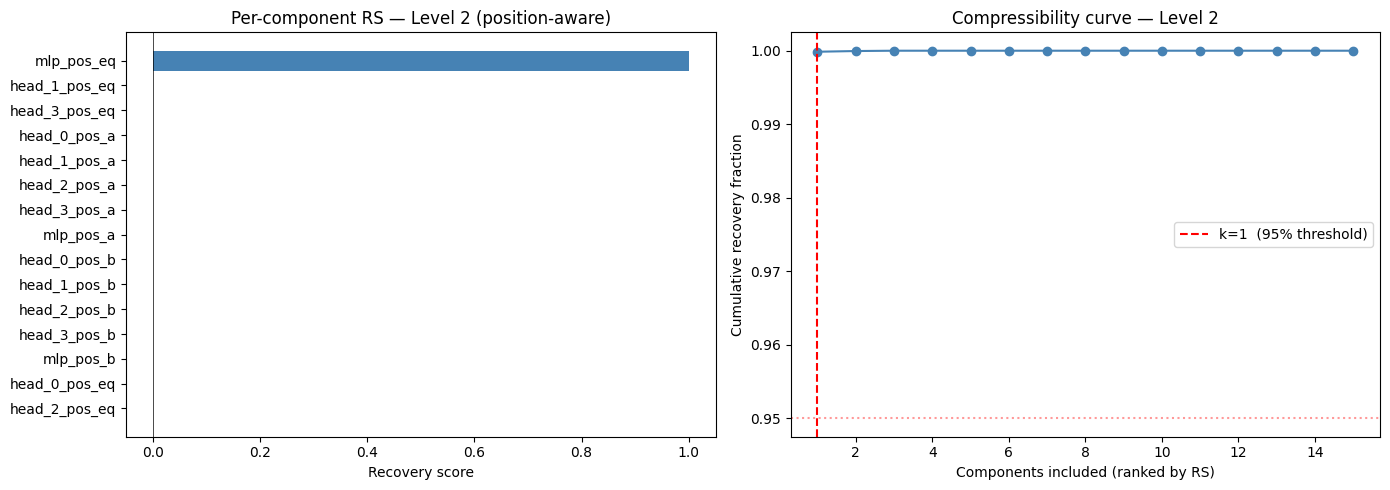

In [28]:
sorted_components = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_components]
scores_sorted = torch.tensor([x[1] for x in sorted_components])

pos_scores = scores_sorted.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_components = names_sorted[:k_95]

# Criterion 1: run the k_95 circuit together
def make_circuit_hooks(circuit_names):
    hooks = []
    for hook_point in HOOKS:
        mean = mean_acts[hook_point].to(device)
        clean = clean_acts[hook_point].to(device)

        # Find which (head, pos) pairs to restore for this hook
        restore_pairs = []
        for comp in COMPONENTS:
            if comp["name"] in circuit_names and comp["hook"] == hook_point:
                restore_pairs.append((comp["head_idx"], comp["pos"]))

        if "hook_result" in hook_point:
            def h(value, hook, m=mean, cl=clean, rp=restore_pairs):
                value[:] = m.unsqueeze(0).expand_as(value)
                for head_i, pos_i in rp:
                    value[:, pos_i, head_i, :] = cl[:, pos_i, head_i, :]
                return value
        else:
            def h(value, hook, m=mean, cl=clean, rp=restore_pairs):
                value[:] = m.unsqueeze(0).expand_as(value)
                for _, pos_i in rp:
                    value[:, pos_i, :] = cl[:, pos_i, :]
                return value

        hooks.append((hook_point, h))
    return hooks

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=make_circuit_hooks(circuit_components))[:, -1, :]
circuit_metric = logit_of_correct(circuit_logits, eval_y)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)


print("Level 2: Attention heads / MLP (position-aware)")
print(f"Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"Criterion 2  Component count : {k_95} / {len(COMPONENTS)} components")
print(f"Compression ratio: {k_95/len(COMPONENTS):.3f}")
print(f"\nCircuit components:")
for c in circuit_components:
    print(f"{c}")


# --- Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue" if n in circuit_components else "lightgray" for n in names_sorted]
bars = ax1.barh(names_sorted[::-1], scores_sorted.numpy()[::-1], color=colors[::-1])
ax1.axvline(0, color="black", linewidth=0.5)
ax1.set_xlabel("Recovery score")
ax1.set_title("Per-component RS — Level 2 (position-aware)")

ax2.plot(range(1, len(COMPONENTS) + 1),cumulative.numpy() / total_pos, "o-", color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--",label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Components included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 2")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level2_recovery_scores.png", dpi=150)
plt.show()

Save Results

In [29]:
results = {
    "level": 2,
    "task": "modular_arithmetic_mod113",
    "n_eval": N_EVAL,
    "n_components": len(COMPONENTS),
    "components": [c["name"] for c in COMPONENTS],
    "clean_metric_mean":       clean_metric.mean().item(),
    "corrupted_metric_mean":   corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / len(COMPONENTS),
    "circuit_components": circuit_components,
    "all_recovery_scores": scores,
}

with open(RESULTS_DIR / "level2_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level2_results.json")

Results saved to ..\results\level2/level2_results.json
